### Geometry optimization



#### Manual determination of a bond length



The equilibrium bond length of a CO molecule is approximately the bond length that minimizes the total energy. We can find that by computing the total energy as a function of bond length, and noting where the minimum is. Here is an example in VASP. There are a few features to point out here. We want to compute 5 bond lengths, and each calculation is independent of all the others. mod:vasp is set up to automatically handle jobs for you by submitting them to the queue. It raises a variety of exceptions to let you know what has happened, and you must handle these to control the workflow. We will illustrate this by the following examples.



d = 1.05 ang
energy = -14.215 eV
forces = (eV/ang)
 [[-14.93238118   0.          -0.        ]
 [ 14.93238118   0.           0.        ]]

d = 1.10 ang
energy = -14.721 eV
forces = (eV/ang)
 [[-5.82096073  0.         -0.        ]
 [ 5.82096073 -0.          0.        ]]

d = 1.15 ang
energy = -14.841 eV
forces = (eV/ang)
 [[ 0.63464585 -0.          0.        ]
 [-0.63464585  0.         -0.        ]]

d = 1.20 ang
energy = -14.691 eV
forces = (eV/ang)
 [[ 5.09089107  0.         -0.        ]
 [-5.09089107 -0.          0.        ]]

d = 1.25 ang
energy = -14.355 eV
forces = (eV/ang)
 [[ 8.14104766  0.         -0.        ]
 [-8.14104766  0.          0.        ]]



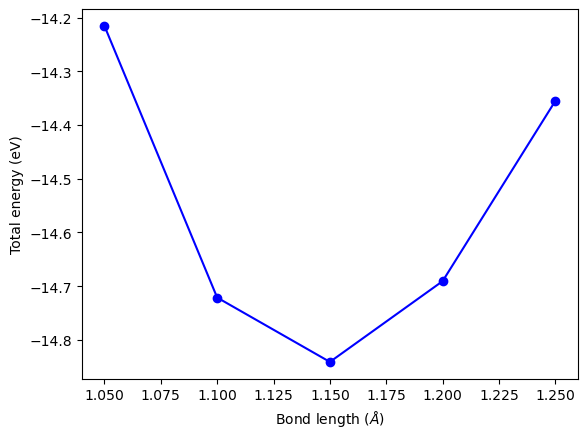

In [1]:
from vasp import Vasp
from ase import Atom, Atoms

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
energies = []

for d in bond_lengths:  # possible bond lengths

    co = Atoms([Atom('C', [0, 0, 0]),
                Atom('O', [d, 0, 0])],
               cell=(6, 6, 6))

    calc = Vasp(label='molecules/co-{0}'.format(d),  # output dir
                xc='PBE',
                nbands=6,
                encut=350,
                ismear=1,
                sigma=0.01,
                atoms=co)

    energies.append(co.get_potential_energy())
    print('d = {0:1.2f} ang'.format(d))
    print('energy = {0:1.3f} eV'.format(energies[-1] or 0))
    print('forces = (eV/ang)\n {0}'.format(co.get_forces()))
    print('')  # blank line

if None in energies:
    calc.abort()
else:
    import matplotlib.pyplot as plt
    plt.plot(bond_lengths, energies, 'bo-')
    plt.xlabel(r'Bond length ($\AA$)')
    plt.ylabel('Total energy (eV)')


Before continuing, it is worth looking at some other approaches to setup and run these calculations. Here we consider a functional approach that uses list comprehensions pretty extensively.



In [2]:
from vasp import Vasp
from ase import Atom, Atoms

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]

ATOMS = [Atoms([Atom('C', [0, 0, 0]),
                Atom('O', [d, 0, 0])],
               cell=(6, 6, 6))
         for d in bond_lengths]

calcs = [Vasp(label='molecules/co-{0}'.format(d),  # output dir
                xc='PBE',
                nbands=6,
                encut=350,
                ismear=1,
                sigma=0.01,
                atoms=atoms)
         for d, atoms in zip(bond_lengths, ATOMS)]

energies = [atoms.get_potential_energy() for atoms in ATOMS]

print(energies)

[-14.21546263, -14.72135721, -14.84115172, -14.69072754, -14.35508357]


We can retrieve data similarly.



In [3]:
from ase.io import read
import os

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
energies = []

for d in bond_lengths:
    outcar = 'molecules/co-{0}/OUTCAR'.format(d)
    if os.path.exists(outcar):
        atoms = read(outcar)
        energies.append(atoms.get_potential_energy())
    else:
        print(f'Missing: {outcar}')

print(energies)


[-14.21546263, -14.72135721, -14.84115172, -14.69072754, -14.35508357]


In [4]:
from vasp import Vasp
from ase.db import connect
from ase.io import read
import os

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]

con = connect('co-database.db', append=False)
for d in bond_lengths:
    directory = 'molecules/co-{0}'.format(d)
    outcar = os.path.join(directory, 'OUTCAR')
    if os.path.exists(outcar):
        atoms = read(outcar)
        con.write(atoms, bond_length=d)
        print(f'Added d={d}, E={atoms.get_potential_energy():.4f} eV')
    else:
        print(f'Calculation not found: {directory}')

Added d=1.05, E=-14.2155 eV
Added d=1.1, E=-14.7214 eV
Added d=1.15, E=-14.8412 eV
Added d=1.2, E=-14.6907 eV
Added d=1.25, E=-14.3551 eV


Here we just show that there are entries in our database. If you run the code above many times, each time will add new entries.

    
This database is now readable in Python too. Here we read in all the results. Later we will learn how to select specific entries.



! ase-db co-database.db

In [5]:
from ase.db import connect

con = connect('co-database.db')
print('Bond lengths and energies from database:')
bond_lengths = []
energies = []
for row in con.select():
    atoms = row.toatoms()
    d = atoms[0].x - atoms[1].x
    e = row.energy
    bond_lengths.append(abs(d))
    energies.append(e)
    print(f'  d={abs(d):.2f} A, E={e:.4f} eV')

print(f'\nBond lengths: {bond_lengths}')
print(f'Energies: {energies}')

Bond lengths and energies from database:
  d=1.05 A, E=-14.2155 eV
  d=1.10 A, E=-14.7214 eV
  d=1.15 A, E=-14.8412 eV
  d=1.20 A, E=-14.6907 eV
  d=1.25 A, E=-14.3551 eV

Bond lengths: [1.05, 1.1, 1.15, 1.2, 1.25]
Energies: [-14.21546263, -14.72135721, -14.84115172, -14.69072754, -14.35508357]


Now, back to the goal of finding the minimum. To find the minimum we could run more calculations, but a simpler and faster way is to fit a polynomial to the data, and find the analytical minimum. The results are shown in Figure ref:fig:co-bondlengths.



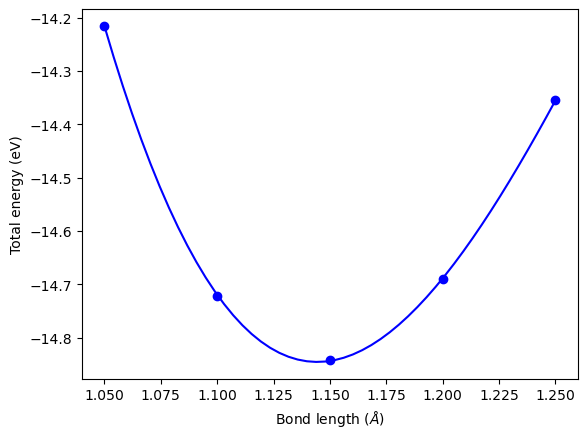

In [6]:
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
import os

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
energies = []

for d in bond_lengths:
    outcar = 'molecules/co-{0}/OUTCAR'.format(d)
    if os.path.exists(outcar):
        atoms = read(outcar)
        energies.append(atoms.get_potential_energy())
    else:
        energies.append(np.nan)

pars = np.polyfit(bond_lengths, energies, 3)
xfit = np.linspace(1.05, 1.25)
efit = np.polyval(pars, xfit)

plt.figure()
plt.plot(bond_lengths, energies, 'bo')
plt.plot(xfit, efit, 'b-')
plt.xlabel('Bond length ($\AA$)')
plt.ylabel('Total energy (eV)')
plt.show()


    The minimum energy is -14.8458440947 eV at V = 1.14437582331 Ang^3


#### Automatic geometry optimization with VASP



It is generally the case that the equilibrium geometry of a system is the one that minimizes the total energy and forces. Since each atom has three degrees of freedom, you can quickly get a high dimensional optimization problem. Luckily, VASP has built-in geometry optimization using the [BROKEN LINK: incar:IBRION] and [BROKEN LINK: incar:NSW] tags. Here we compute the bond length for a CO molecule, letting VASP do the geometry optimization for us.

Here are the most common choices for IBRION.


| IBRION value|algorithm|
|---|---|
| 1|quasi-Newton    (use if initial guess is good)|
| 2|conjugate gradient|

<div class="note" id="orgea5c6af">
<p>
VASP applies a criteria for stopping a geometry optimization. When the change in energy between two steps is less than 0.001 eV (or 10*EDIFF), the relaxation is stopped. This criteria is controlled by the incar:EDIFFG tag. If you prefer to stop based on forces, set EDIFFG=-0.05, i.e. to a negative number. The units of force is eV/&Aring;. For most work, a force tolerance of 0.05 eV/&Aring; is usually sufficient.
</p>

</div>



In [7]:
from ase import Atom, Atoms
from vasp import Vasp

co = Atoms([Atom('C',[0, 0, 0]),
            Atom('O',[1.2, 0, 0])],
            cell=(6, 6, 6))

calc = Vasp(label='molecules/co-cg',
          xc='PBE',
          nbands=6,
          encut=350,
          ismear=1,
          sigma=0.01, # this is small for a molecule
          ibrion=2,   # conjugate gradient optimizer
          nsw=5,      # do at least 5 steps to relax
          atoms=co)

print('Forces')
print('=======')
print(co.get_forces())

pos = co.get_positions()
d = ((pos[0] - pos[1])**2).sum()**0.5
print('Bondlength = {0:1.2f} angstroms'.format(d))

Forces
[[-0.83553038  0.         -0.        ]
 [ 0.83553038 -0.          0.        ]]
Bondlength = 1.14 angstroms


#### Relaxation of a water molecule



It is not more complicated to relax more atoms, it just may take longer because there are more electrons and degrees of freedom. Here we relax a water molecule which has three atoms.



In [8]:
from ase import Atoms, Atom
from vasp import Vasp

atoms = Atoms([Atom('H', [0.5960812, -0.7677068, 0.0000000]),
               Atom('O', [0.0000000,  0.0000000, 0.0000000]),
               Atom('H', [0.5960812,  0.7677068, 0.0000000])],
              cell=(8, 8, 8))

atoms.center()

calc = Vasp(label='molecules/h2o-relax-centered',
            xc='PBE',
            encut=400,
            ismear=0,  # Gaussian smearing
            ibrion=2,
            ediff=1e-8,
            nsw=10,
            atoms=atoms)

print("forces")
print('=======')
print(atoms.get_forces())

forces
[[-3.506e-05  5.076e-05  0.000e+00]
 [ 7.013e-05  0.000e+00  0.000e+00]
 [-3.506e-05 -5.076e-05  0.000e+00]]


In [12]:
from vasp import Vasp

from ase.io import read
import os

calc = Vasp(label='molecules/h2o-relax-centered')
traj_file = 'molecules/h2o-relax-centered/OUTCAR'
if os.path.exists(traj_file):
    images = read(traj_file, index=':')

images

[Atoms(symbols='H2O', pbc=True, cell=[8.0, 8.0, 8.0], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='H2O', pbc=True, cell=[8.0, 8.0, 8.0], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='H2O', pbc=True, cell=[8.0, 8.0, 8.0], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='H2O', pbc=True, cell=[8.0, 8.0, 8.0], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='H2O', pbc=True, cell=[8.0, 8.0, 8.0], calculator=SinglePointDFTCalculator(...))]